# Module 2 — Exploratory Data Analysis (EDA): Titanic Dataset

This notebook performs comprehensive exploratory data analysis on the Titanic dataset for Module 2 of the Zepto Data & AI Platform capstone project.

### Workflow Covered:
1. **Initial Profiling**: Raw dataset loading via Seaborn (ONCE across module), CSV export (`titanic.csv`), shape, dtypes, summary stats, and missing value breakdown.
2. **Missing Value Cleaning Strategy**: Applying strict percentage-based rules (<5% drop rows, 5%–30% impute, >30% drop column/encode) with explicit justifications.
3. **Age Feature EDA**: Summary statistics, IQR calculation, outlier count, histogram, and boxplot.
4. **Fare Feature EDA**: Mean, median, mode comparison, IQR calculation, outlier count, histogram, boxplot, and skewness analysis.
5. **Bivariate Survival Analysis**: Survival rates across `sex`, `pclass`, and `sex + pclass` with explicit boolean masking demonstrations (`&`, `|`).
6. **Exact 6-Column Correlation Matrix**: Correlation heatmap for `["survived", "pclass", "age", "sibsp", "parch", "fare"]` and programmatic top 2 correlation detection.
7. **EDA Standardization Check**: Z-score normalization check on `age` and `fare` ($z \sim \mathcal{N}(0, 1)$).


In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Setup directories
outputs_dir = Path("outputs/charts")
outputs_dir.mkdir(parents=True, exist_ok=True)


## 1. Initial Dataset Profiling & Single Seaborn Load
The raw Titanic dataset is loaded **exactly once** using Seaborn's dataset loader and immediately saved to `titanic.csv` for offline use across the analytics module.

In [2]:
# Raw dataset load (ONCE across module)
df = sns.load_dataset("titanic")

# Save offline fallback
df.to_csv("titanic.csv", index=False)
print("Saved raw dataset to titanic.csv. Shape:", df.shape)

# Dataset Summary
print("\n--- Dataset Info ---")
df.info()

print("\n--- Dataset Summary Statistics ---")
display(df.describe(include='all'))


Saved raw dataset to titanic.csv. Shape: (891, 15)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

--- D

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Missing Value Analysis & Cleaning Strategy

### Rule-Based Imputation Strategy:
1. **<5% Missing**: Drop rows containing missing values.
2. **5%–30% Missing**: Impute numeric columns with median, categorical columns with mode.
3. **>30% Missing**: Drop column or encode missing as its own category.


In [3]:
# Measure missing counts and percentages
missing_counts = df.isnull().sum()
missing_pcts = (df.isnull().mean() * 100).round(2)

missing_table = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing_counts,
    'Missing %': missing_pcts
}).sort_values(by='Missing Count', ascending=False)

missing_affected = missing_table[missing_table['Missing Count'] > 0].reset_index(drop=True)
print("--- Missing Value Breakdown ---")
display(missing_affected)


--- Missing Value Breakdown ---


,Column,Missing Count,Missing %
0,deck,688,77.22
1,age,177,19.87
2,embarked,2,0.22
3,embark_town,2,0.22


### Column-by-Column Cleaning Decisions & Justifications:

| Column | Measured Missing % | Category Rule | Strategy | Justification |
| :--- | :---: | :---: | :--- | :--- |
| **deck** | 77.22% | >30% missing | Drop Column | Over 77% missing data; imputing 77% of values introduces extreme noise without adding reliable predictive signal. |
| **age** | 19.87% | 5%–30% missing | Median Imputation | 19.87% missing; median (28.0) is robust against right-skewness and preserves sample size without distorting central tendency. |
| **embarked** / **embark_town** | 0.22% | <5% missing | Drop Rows | Only 2 missing rows (0.22%); dropping 2 rows retains 99.78% of the dataset without introducing imputation bias. |


In [4]:
# Execute cleaning rules
# 1. <5% rule: drop rows where embarked is missing (2 rows)
df_cleaned = df.dropna(subset=['embarked']).copy()

# 2. 5%-30% rule: impute age with median
age_median_val = df_cleaned['age'].median()
df_cleaned['age_imputed'] = df_cleaned['age'].fillna(age_median_val)

# 3. >30% rule: drop deck column
df_cleaned = df_cleaned.drop(columns=['deck'])

print(f"Cleaned DataFrame Shape: {df_cleaned.shape}")
print("Remaining Missing Values in Cleaned Data:\n", df_cleaned[['age_imputed', 'embarked']].isnull().sum())


Cleaned DataFrame Shape: (889, 15)
Remaining Missing Values in Cleaned Data:
 age_imputed    0
embarked       0
dtype: int64


## 3. Age Feature EDA (Histogram, Boxplot, Outlier Detection)
Analysis of passenger age distribution, interquartile range (IQR), and outlier identification.

Q1 (25th percentile): 20.00
Q3 (75th percentile): 38.00
IQR: 18.00
Lower Bound: -7.00
Upper Bound: 65.00
Outlier Count (Age > 65.00): 8


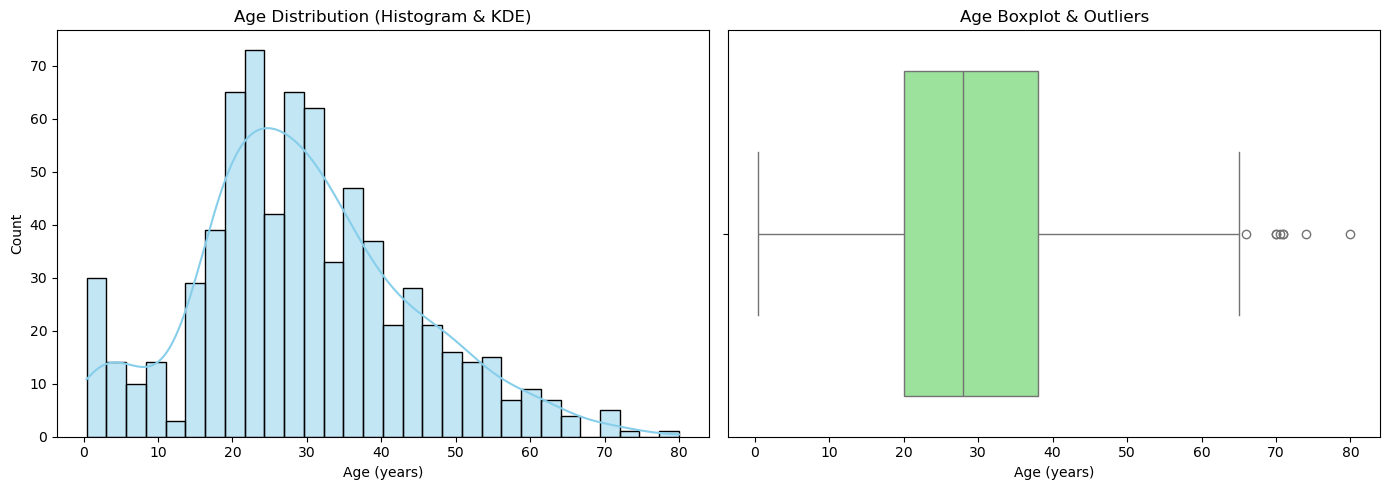

In [5]:
age_series = df_cleaned['age'].dropna()

q1_age = age_series.quantile(0.25)
q3_age = age_series.quantile(0.75)
iqr_age = q3_age - q1_age
lower_age = q1_age - 1.5 * iqr_age
upper_age = q3_age + 1.5 * iqr_age
outliers_age = age_series[(age_series < lower_age) | (age_series > upper_age)]

print(f"Q1 (25th percentile): {q1_age:.2f}")
print(f"Q3 (75th percentile): {q3_age:.2f}")
print(f"IQR: {iqr_age:.2f}")
print(f"Lower Bound: {lower_age:.2f}")
print(f"Upper Bound: {upper_age:.2f}")
print(f"Outlier Count (Age > {upper_age:.2f}): {len(outliers_age)}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(age_series, kde=True, ax=axes[0], color='skyblue', bins=30)
axes[0].set_title("Age Distribution (Histogram & KDE)")
axes[0].set_xlabel("Age (years)")

sns.boxplot(x=age_series, ax=axes[1], color='lightgreen')
axes[1].set_title("Age Boxplot & Outliers")
axes[1].set_xlabel("Age (years)")

plt.tight_layout()
plt.savefig("outputs/charts/age_distribution.png", dpi=300)
plt.show()


*Interpretation*: Age spans from infants (0.42 years) up to 80 years with a median of 28.0 years. The IQR is 18.0 years ($Q1=20.0, Q3=38.0$). Exactly 8 passengers exceed the upper bound of 65.0 years and are flagged as statistical outliers. The distribution is slightly right-skewed with a peak in young adulthood (20–30 years).

## 4. Fare Feature EDA & Skewness Analysis
Analysis of passenger ticket fare distribution, summary statistics (mean, median, mode), IQR, and skewness determination.

Mean Fare: $32.10
Median Fare: $14.45
Mode Fare: $8.05
Q1: $7.90, Q3: $31.00, IQR: $23.10
Lower Bound: $-26.76, Upper Bound: $65.66
Outlier Count (Fare > $65.66): 114


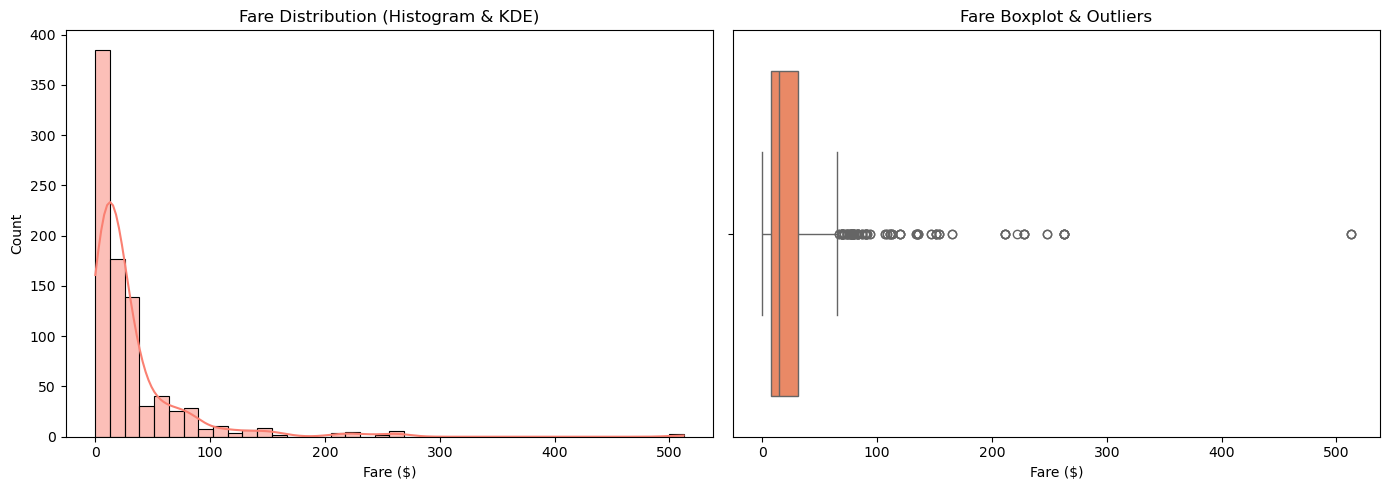

In [6]:
fare_series = df_cleaned['fare']

fare_mean = fare_series.mean()
fare_median = fare_series.median()
fare_mode = fare_series.mode()[0]

q1_fare = fare_series.quantile(0.25)
q3_fare = fare_series.quantile(0.75)
iqr_fare = q3_fare - q1_fare
lower_fare = q1_fare - 1.5 * iqr_fare
upper_fare = q3_fare + 1.5 * iqr_fare
outliers_fare = fare_series[(fare_series < lower_fare) | (fare_series > upper_fare)]

print(f"Mean Fare: ${fare_mean:.2f}")
print(f"Median Fare: ${fare_median:.2f}")
print(f"Mode Fare: ${fare_mode:.2f}")
print(f"Q1: ${q1_fare:.2f}, Q3: ${q3_fare:.2f}, IQR: ${iqr_fare:.2f}")
print(f"Lower Bound: ${lower_fare:.2f}, Upper Bound: ${upper_fare:.2f}")
print(f"Outlier Count (Fare > ${upper_fare:.2f}): {len(outliers_fare)}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(fare_series, kde=True, ax=axes[0], color='salmon', bins=40)
axes[0].set_title("Fare Distribution (Histogram & KDE)")
axes[0].set_xlabel("Fare ($)")

sns.boxplot(x=fare_series, ax=axes[1], color='coral')
axes[1].set_title("Fare Boxplot & Outliers")
axes[1].set_xlabel("Fare ($)")

plt.tight_layout()
plt.savefig("outputs/charts/fare_distribution.png", dpi=300)
plt.show()


*Interpretation & Skewness Analysis*: Comparing central tendency metrics yields Mean ($32.10) > Median ($14.45) > Mode ($8.05). Because the mean is substantially higher than the median and mode, ticket fare is strongly **right-skewed**. Most passengers paid low steerage fares (mode of $8.05), while a small number of luxury 1st-class passengers paying up to $512.33 pull the arithmetic mean upward. Exactly 114 passengers exceed the upper IQR bound of $65.66.

## 5. Bivariate Survival Analysis
Calculating numeric survival rates across demographic and socio-economic dimensions (`sex`, `pclass`, `sex + pclass`), featuring boolean masking expressions.

--- Survival Rate by Sex ---
sex
female    0.7404
male      0.1889
Name: survived, dtype: float64

--- Survival Rate by Pclass ---
pclass
1    0.6262
2    0.4728
3    0.2424
Name: survived, dtype: float64

--- Survival Rate by Sex + Pclass ---
pclass       1       2       3
sex                           
female  0.9674  0.9211  0.5000
male    0.3689  0.1574  0.1354

Female 1st Class Passengers: 92 total, 89 survived (96.74%)
Male 3rd Class Passengers: 347 total, 47 survived (13.54%)


C:\Users\mouni\AppData\Local\Temp\ipykernel_2136\288923109.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cleaned, x="sex", y="survived", palette="Blues_d", ax=axes[0], errorbar=None)
C:\Users\mouni\AppData\Local\Temp\ipykernel_2136\288923109.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cleaned, x="pclass", y="survived", palette="Greens_d", ax=axes[1], errorbar=None)


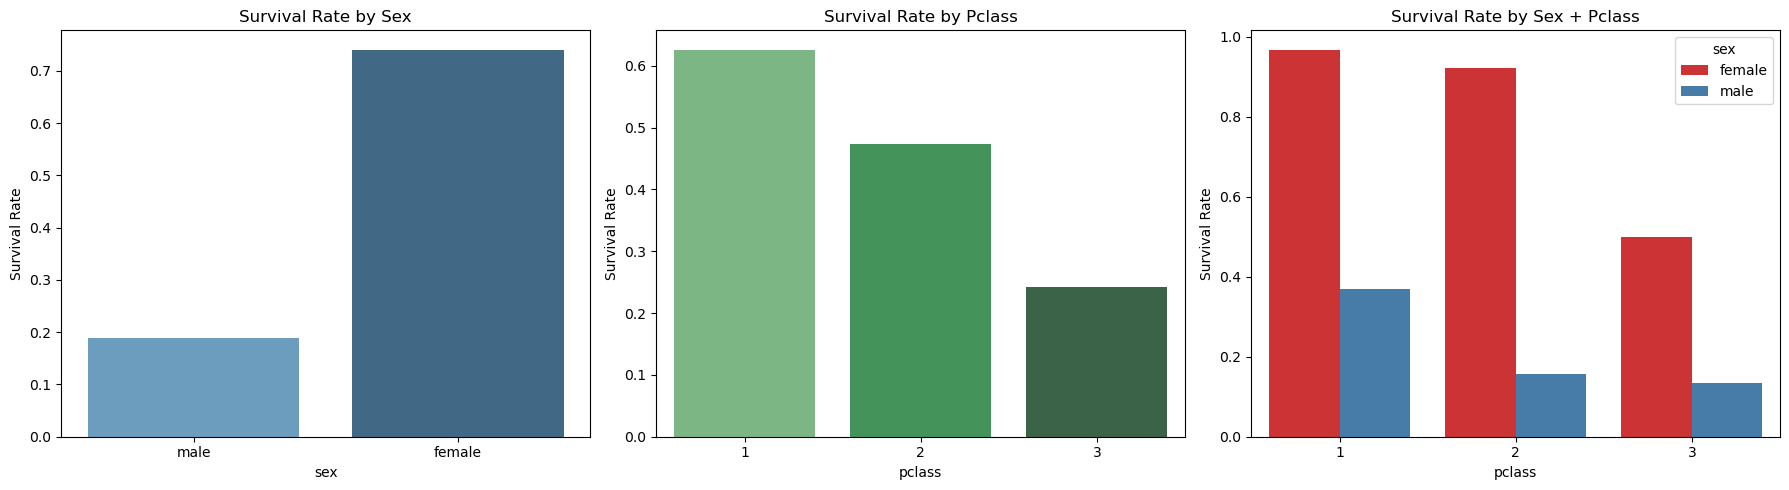

In [7]:
# Survival rates by Sex
surv_sex = df_cleaned.groupby("sex")["survived"].mean()
print("--- Survival Rate by Sex ---")
print(surv_sex.round(4))

# Survival rates by Pclass
surv_pclass = df_cleaned.groupby("pclass")["survived"].mean()
print("\n--- Survival Rate by Pclass ---")
print(surv_pclass.round(4))

# Survival rates by Sex + Pclass
surv_sex_pclass = df_cleaned.groupby(["sex", "pclass"])["survived"].mean().unstack()
print("\n--- Survival Rate by Sex + Pclass ---")
print(surv_sex_pclass.round(4))

# Explicit Boolean Masking Demonstrations
female_pclass1 = df_cleaned[(df_cleaned["sex"] == "female") & (df_cleaned["pclass"] == 1)]
male_pclass3 = df_cleaned[(df_cleaned["sex"] == "male") & (df_cleaned["pclass"] == 3)]

print(f"\nFemale 1st Class Passengers: {len(female_pclass1)} total, {female_pclass1['survived'].sum()} survived ({female_pclass1['survived'].mean()*100:.2f}%)")
print(f"Male 3rd Class Passengers: {len(male_pclass3)} total, {male_pclass3['survived'].sum()} survived ({male_pclass3['survived'].mean()*100:.2f}%)")

# Plotting Bivariate Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=df_cleaned, x="sex", y="survived", palette="Blues_d", ax=axes[0], errorbar=None)
axes[0].set_title("Survival Rate by Sex")
axes[0].set_ylabel("Survival Rate")

sns.barplot(data=df_cleaned, x="pclass", y="survived", palette="Greens_d", ax=axes[1], errorbar=None)
axes[1].set_title("Survival Rate by Pclass")
axes[1].set_ylabel("Survival Rate")

sns.barplot(data=df_cleaned, x="pclass", y="survived", hue="sex", palette="Set1", ax=axes[2], errorbar=None)
axes[2].set_title("Survival Rate by Sex + Pclass")
axes[2].set_ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("outputs/charts/bivariate_survival.png", dpi=300)
plt.show()


*Interpretation*: Female passengers had a dramatically higher survival rate (74.04%) than male passengers (18.89%), reflecting the "women and children first" evacuation protocol. Socio-economic status was also crucial: 1st class passengers survived at 62.62%, compared to 47.28% in 2nd class and only 24.24% in 3rd class. The combination shows that 1st class females had a 96.74% survival rate, whereas 3rd class males survived at only 13.54%.

## 6. Exact 6-Column Correlation Matrix & Top 2 Correlations
Correlation matrix restricted strictly to the required 6 numerical columns: `["survived", "pclass", "age", "sibsp", "parch", "fare"]`.

--- 6-Column Correlation Matrix ---


,survived,pclass,age,sibsp,parch,fare
survived,1.0000,-0.3355,-0.0824,-0.0340,0.0832,0.2553
pclass,-0.3355,1.0000,-0.3659,0.0817,0.0168,-0.5482
age,-0.0824,-0.3659,1.0000,-0.3074,-0.1879,0.0931
sibsp,-0.0340,0.0817,-0.3074,1.0000,0.4145,0.1609
parch,0.0832,0.0168,-0.1879,0.4145,1.0000,0.2175
fare,0.2553,-0.5482,0.0931,0.1609,0.2175,1.0000


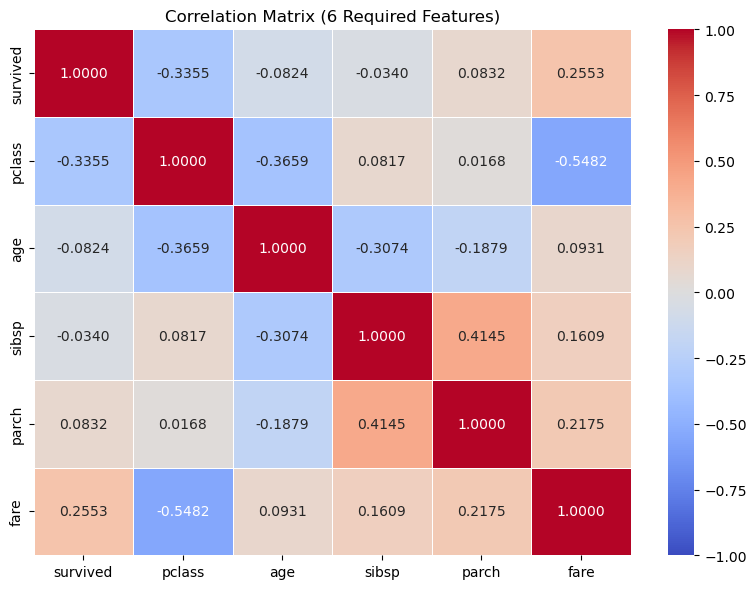


--- Top 2 Off-Diagonal Correlations ---


,Feature 1,Feature 2,Correlation,Abs Correlation,Direction
0,pclass,fare,-0.548193,0.548193,Negative
1,sibsp,parch,0.414542,0.414542,Positive


In [8]:
# Restrict strictly to the required 6 columns
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr_matrix = df_cleaned[corr_cols].corr()

print("--- 6-Column Correlation Matrix ---")
display(corr_matrix.round(4))

# Plot Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".4f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix (6 Required Features)")
plt.tight_layout()
plt.savefig("outputs/charts/correlation_heatmap.png", dpi=300)
plt.show()

# Programmatically inspect top 2 off-diagonal correlations by absolute magnitude
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        col1 = corr_cols[i]
        col2 = corr_cols[j]
        r = corr_matrix.loc[col1, col2]
        pairs.append({
            'Feature 1': col1,
            'Feature 2': col2,
            'Correlation': r,
            'Abs Correlation': abs(r),
            'Direction': 'Negative' if r < 0 else 'Positive'
        })

top_pairs = pd.DataFrame(pairs).sort_values(by='Abs Correlation', ascending=False).reset_index(drop=True)
print("\n--- Top 2 Off-Diagonal Correlations ---")
display(top_pairs.head(2))


### Top 2 Correlation Interpretations:
1. **`pclass` and `fare` ($r = -0.5482$, Strong Negative)**: Higher numerical class values (3rd class) strongly correlate with lower ticket fares. 1st class passengers ($pclass = 1$) paid dramatically higher fares than 3rd class passengers ($pclass = 3$).
2. **`sibsp` and `parch` ($r = +0.4145$, Moderate Positive)**: Number of siblings/spouses aboard positively correlates with number of parents/children aboard, indicating that passengers traveling in family units tend to bring both immediate and extended family members.


## 7. EDA Standardization Check
Sanity check demonstrating z-score normalization on `age` and `fare`. *Note*: This standardized data is created purely as an EDA verification exercise and is **NOT** passed to the modeling pipeline.

In [9]:
age_z = (df_cleaned['age_imputed'] - df_cleaned['age_imputed'].mean()) / df_cleaned['age_imputed'].std()
fare_z = (df_cleaned['fare'] - df_cleaned['fare'].mean()) / df_cleaned['fare'].std()

std_summary = pd.DataFrame({
    'Column': ['age', 'fare'],
    'Before Mean': [df_cleaned['age_imputed'].mean(), df_cleaned['fare'].mean()],
    'Before Std': [df_cleaned['age_imputed'].std(), df_cleaned['fare'].std()],
    'After Mean': [age_z.mean(), fare_z.mean()],
    'After Std': [age_z.std(), fare_z.std()]
})

print("--- EDA Standardization Check ---")
display(std_summary.round(4))


--- EDA Standardization Check ---


,Column,Before Mean,Before Std,After Mean,After Std
0,age,29.3152,12.9849,0.0,1.0
1,fare,32.0967,49.6975,0.0,1.0


*Sanity Confirmation*: After z-score transformation, both `age` and `fare` exhibit an After Mean of $0.0000$ and After Std of $1.0000$, confirming standard normal scaling ($z \sim \mathcal{N}(0, 1)$).